<a href="https://colab.research.google.com/github/dimasbayucmiiw/Kecerdasan-Buatan-2026/blob/main/Praktikum_SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# membaca dataset dan mengubahnya menjadi dataframe
data = pd.read_csv('/content/sample_data/Salary_Data.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [4]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [6]:
import numpy as np

# memisahkan atribut dan label
X = data['YearsExperience']
y = data['Salary']

# mengubah bentuk atribut
X = X.values[:,np.newaxis]

In [7]:
from sklearn.svm import SVR

# membangun model dengan parameter C, gamma, dan kernel
model  = SVR(C=1000, gamma=0.05, kernel='rbf')

# melatih model dengan fungsi fit
model.fit(X,y)

SVR(C=1000, gamma=0.05)

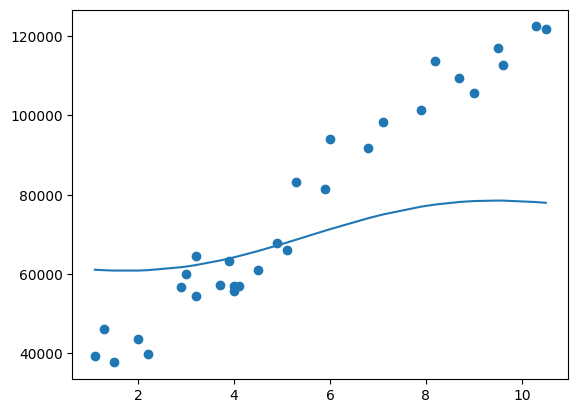

In [8]:
import matplotlib.pyplot as plt

# memvisualisasikan model
plt.scatter(X, y)
plt.plot(X, model.predict(X))

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# 1. Definisikan model dasar SVR
svr_model = SVR()

# 2. Tentukan daftar parameter yang ingin diuji coba
param_grid_svr = {
    'C': [100, 1000, 5000, 10000],
    'gamma': [0.01, 0.05, 0.1, 0.5],
    'kernel': ['rbf', 'linear']
}

# 3. Inisialisasi GridSearchCV
# Catatan: Untuk regresi, scoring bisa menggunakan 'neg_mean_squared_error' atau dibiarkan default (R-squared)
grid_svr = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid_svr,
    cv=5,
    scoring='r2', # Menggunakan koefisien determinasi (R2 Score)
    n_jobs=-1
)

# 4. Latih Grid Search dengan data (X dan y)
grid_svr.fit(X, y)

# 5. Tampilkan hasil parameter terbaik dan skor terbaiknya
print("--- HASIL GRID SEARCH SVR REGRESI ---")
print("Parameter Terbaik :", grid_svr.best_params_)
print("Skor R2 Terbaik   :", grid_svr.best_score_)

# 6. Menggunakan model SVR terbaik untuk melihat hasil prediksi
best_svr = grid_svr.best_estimator_

--- HASIL GRID SEARCH SVR REGRESI ---
Parameter Terbaik : {'C': 1000, 'gamma': 0.01, 'kernel': 'linear'}
Skor R2 Terbaik   : 0.027693280673369892
